In [3]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("IMDB.csv")

# Basic cleaning
def clean_text(text):
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    return text

df["review"] = df["review"].apply(clean_text)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["sentiment"],
    test_size=0.2,
    random_state=42
)

# Build pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, stop_words="english")),
    ("nb", MultinomialNB())
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8622
              precision    recall  f1-score   support

    negative       0.86      0.87      0.86      4961
    positive       0.87      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [ ]:
import joblib
joblib.dump(model, "sentiment_model.pkl")

In [3]:
pip install matplotlib wordcloud seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


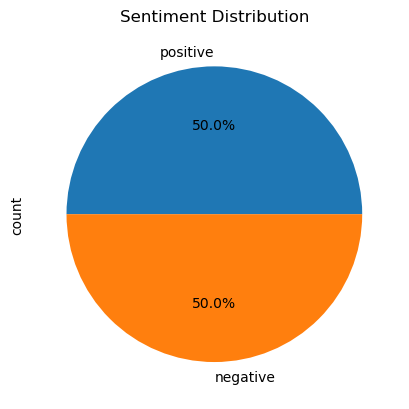

In [4]:
# Pie Chart
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Sentiment Distribution")
plt.show()

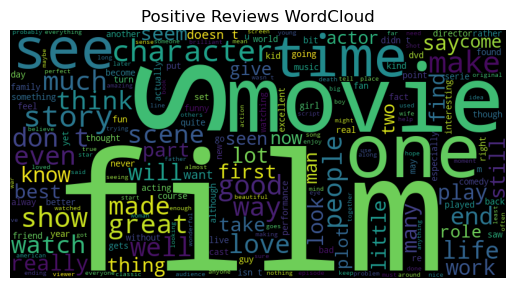

In [5]:
# WordCloud (Positive vs Negative)
from wordcloud import WordCloud

positive_text = " ".join(df[df["sentiment"]=="positive"]["review"])
negative_text = " ".join(df[df["sentiment"]=="negative"]["review"])

wc = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wc)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

In [7]:
!pip install flask


   ---------------------------------------- 2/2 [flask]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
